# Ecuacion de calor con condiciones de Dirichlet (Actividad)

$$\frac{\partial u}{\partial t} + a\frac{\partial u}{\partial x} = D\frac{\partial^2 u}{\partial x^2},\quad x\in(0,1),\; t\ge 0$$

con $u(0,t)=u(1,t)=0$ y $u(x,0)=\sin(4\pi x)$.

## Libraries

In [23]:
import numpy as np
from numpy.linalg import solve, norm
from numpy import pi, exp, sin, cos
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.animation as animation
import pandas as pd
from pathlib import Path

## Archivos de solucion exacta (CSV)


In [24]:
base_dir = Path("/Users/cristobalmedinameza/Desktop/repos/reto-final/notebooks/tareas_chacon/3_2/datos")

exact_files = {
    (1.0, 20): "uexmp_1_2_20.csv",
    (1.0, 40): "uexmp_1_2_40.csv",
    (0.01, 20): "uexmp_001_2_20.csv",
    (0.01, 40): "uexmp_001_2_40.csv",
}

def load_exact(D, N):
    key = (float(D), int(N))
    if key not in exact_files:
        raise KeyError(f"No hay archivos configurados para D={D}, N={N}")
    exact_path = base_dir / exact_files[key]
    if not exact_path.exists():
        raise FileNotFoundError(f"No se encontro: {exact_path}")
    u_exact_grid = np.loadtxt(exact_path, delimiter=",")
    if u_exact_grid.shape[0] != (N + 1):
        u_exact_grid = u_exact_grid.T
    u_exact = u_exact_grid
    return u_exact, u_exact_grid

## Parametros del problema

In [25]:
a = 2.0
D_values = [1.0, 0.01]
N_values = [20, 40]

tmin, tmax = 0.0, 1.0
dt = 0.001

times_to_plot = [0.06, 0.1, 1.0]


def f(x):
    return np.sin(4*np.pi*x)

## Esquemas

Se usan diferencias centradas para $u_x$ y $u_{xx}$.

![Screenshot 2026-04-30 at 16.05.17.png](<attachment:Screenshot 2026-04-30 at 16.05.17.png>)
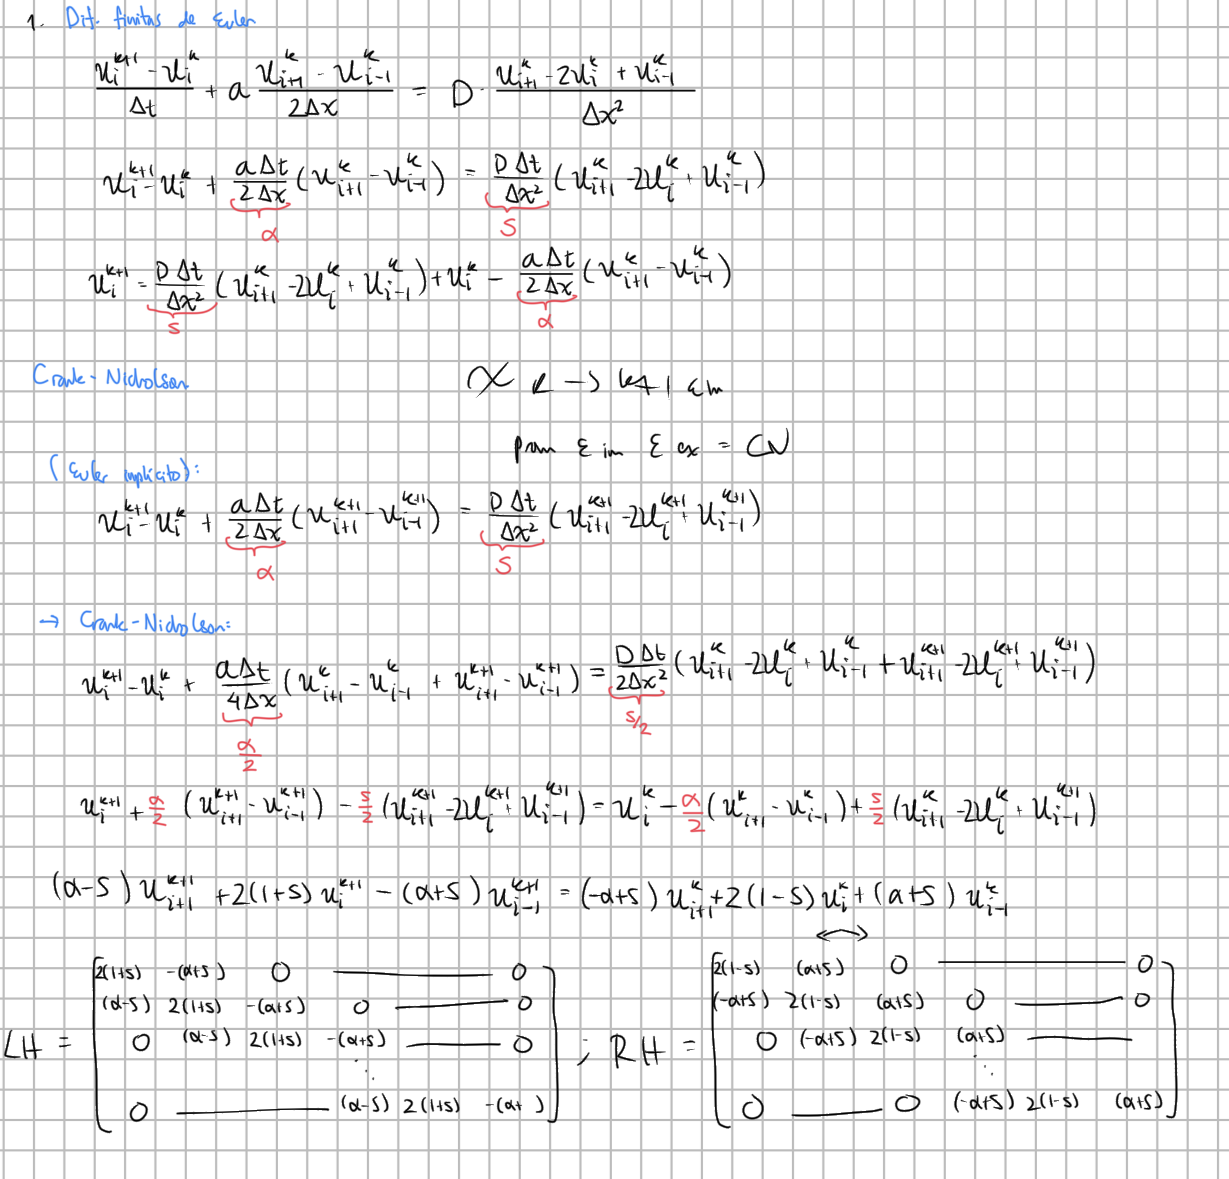

In [26]:
def setup_case(D, N):
    xmin, xmax = 0.0, 1.0
    dx = (xmax - xmin) / N
    x = np.linspace(xmin, xmax, N + 1)
    M = int((tmax - tmin) / dt)
    t = np.linspace(tmin, tmax, M + 1)
    s = D * dt / (dx * dx)
    alpha = a * dt / (2 * dx)
    X, T = np.meshgrid(x, t)
    vmin, vmax = -1.0, 1.0
    levels = np.linspace(vmin, vmax, 21)
    return x, t, dx, M, s, alpha, X, T, levels


def forward_euler(D, N):
    x, t, dx, M, s, alpha, X, T, levels = setup_case(D, N)
    # evitar overflow no quitar
    if s > 0.5 or abs(alpha) > 1.0:
        raise ValueError(
            f"Forward Euler unstable for D={D}, N={N}: s={s:.3f}, alpha={alpha:.3f}. "
            "Reduce dt or N."
        )
    u = np.zeros((N + 1, M + 1))
    u[:, 0] = f(x)
    for k in range(M):
        u[1:-1, k + 1] = (
            u[1:-1, k]
            - alpha * (u[2:, k] - u[:-2, k])
            + s * (u[2:, k] - 2 * u[1:-1, k] + u[:-2, k])
        )
    return u, x, t, X, T, levels


def backward_euler(D, N):
    x, t, dx, M, s, alpha, X, T, levels = setup_case(D, N)
    u = np.zeros((N + 1, M + 1))
    u[:, 0] = f(x)
    n = N - 1
    be_matrix_left = np.diag(2 * (1 + s) * np.ones(n))
    for j in range(1, n - 1):
        be_matrix_left[j, j + 1] = -(alpha + s)
        be_matrix_left[j, j - 1] = (alpha - s)
    be_matrix_left[0, 1] = -(alpha + s)
    be_matrix_left[-1, -2] = (alpha - s)

    for k in range(M):
        utemp = u[1:N, k]
        utemp = solve(be_matrix_left, utemp)
        u[1:N, k + 1] = utemp
    return u, x, t, X, T, levels


def crank_nicolson(D, N):
    x, t, dx, M, s, alpha, X, T, levels = setup_case(D, N)
    u = np.zeros((N + 1, M + 1))
    u[:, 0] = f(x)
    n = N - 1
    cn_matrix_left = np.diag(2 * (1 + s) * np.ones(n))
    cn_matrix_right = np.diag(2 * (1 - s) * np.ones(n))
    for j in range(1, n - 1):
        cn_matrix_left[j, j + 1] = -(alpha + s)
        cn_matrix_left[j, j - 1] = (alpha - s)
        cn_matrix_right[j, j + 1] = (alpha + s)
        cn_matrix_right[j, j - 1] = (-alpha + s)
    cn_matrix_left[0, 1] = -(alpha + s)
    cn_matrix_left[-1, -2] = (alpha - s)
    cn_matrix_right[0, 1] = (alpha + s)
    cn_matrix_right[-1, -2] = (-alpha + s)

    for k in range(M):
        utemp = u[1:N, k]
        utemp = cn_matrix_right @ utemp
        utemp = solve(cn_matrix_left, utemp)
        u[1:N, k + 1] = utemp
    return u, x, t, X, T, levels


def error_at_times(u, u_exact_grid, t, times):
    errs = {}
    for tt in times:
        idx = int(round(tt / dt))
        e = u[:, idx] - u_exact_grid[:, idx]
        errs[tt] = {
            "L2": norm(e) / np.sqrt(u.shape[0]),
            "Linf": norm(e, ord=np.inf),
            "e": e,
        }
    return errs

## Ejecucion de los casos

Para cada par $(D, N)$ se cargan los CSV de solucion exacta, se calculan las tres aproximaciones y se comparan en $t=0.06, 0.1, 1.0$.

=== Caso D=1.0, N=20 ===


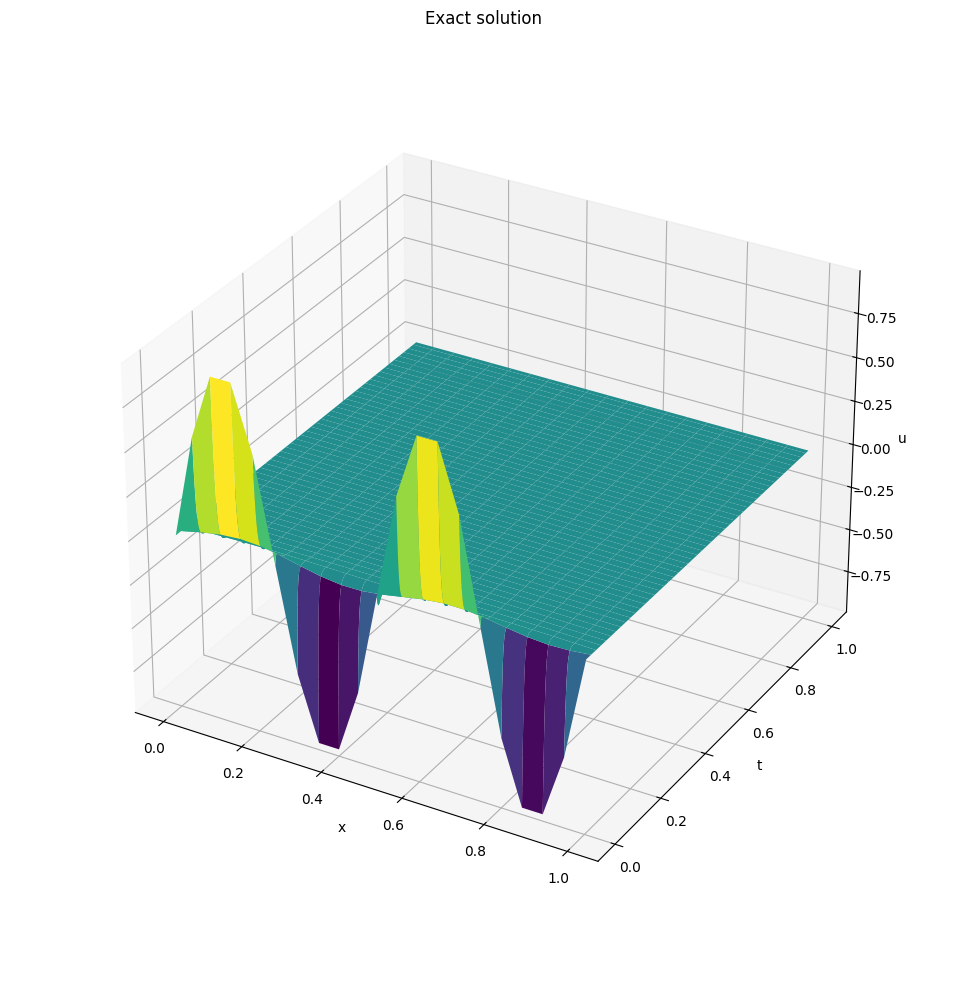

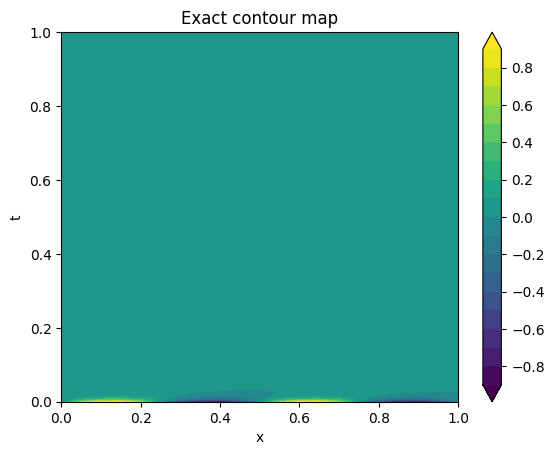

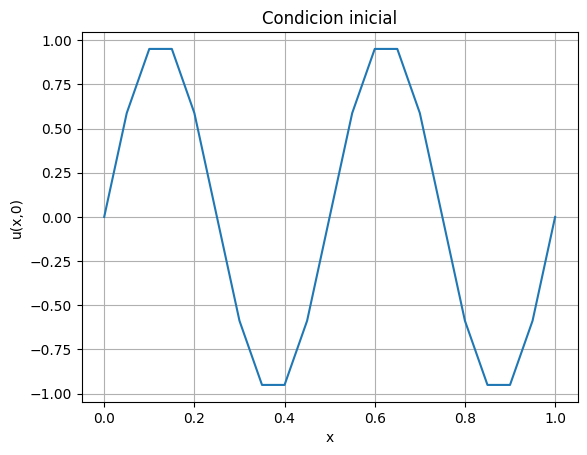

Forward Euler Linf at tmax = 1.988080767486952e-07


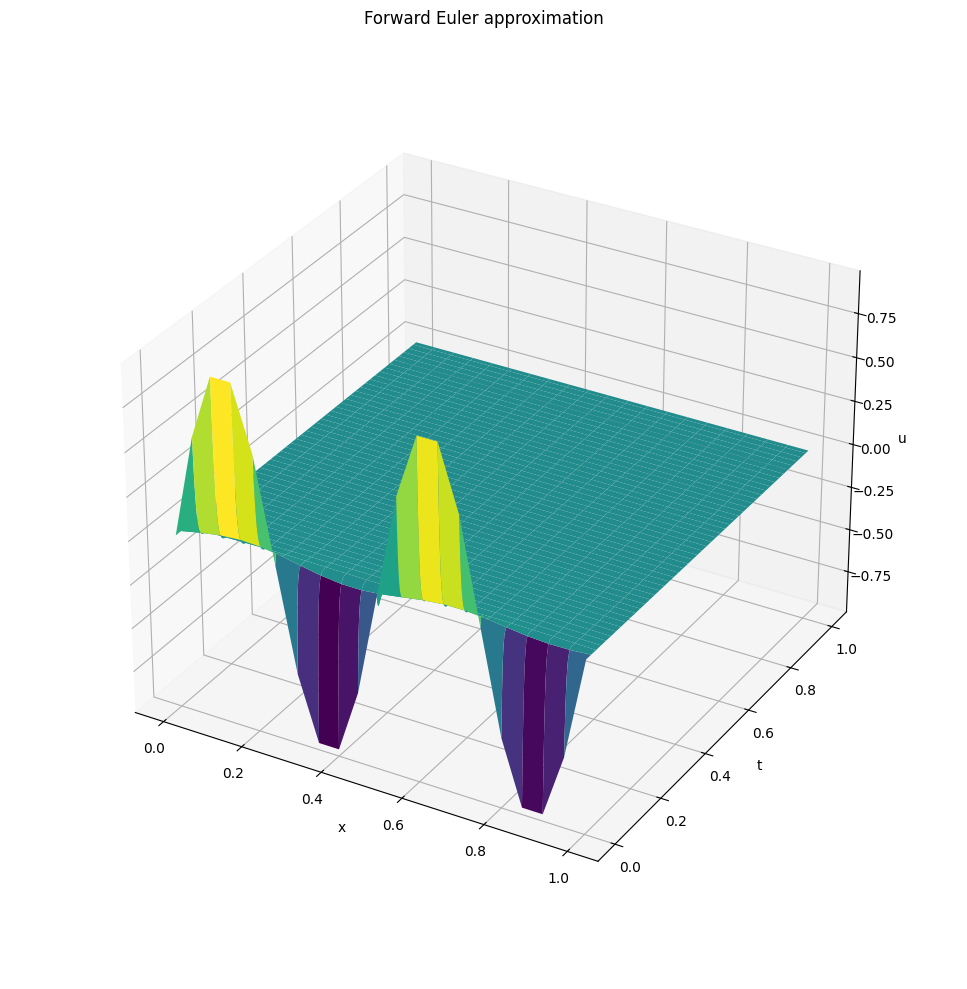

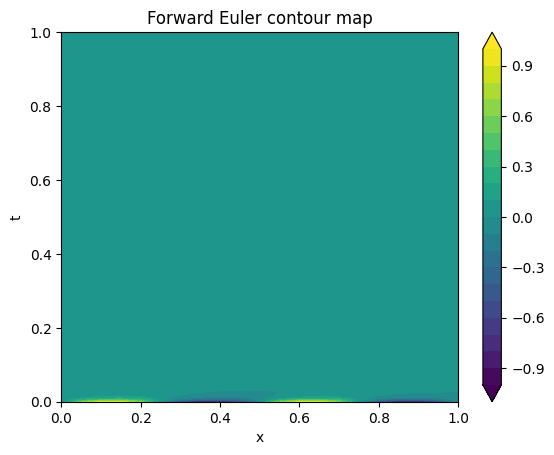

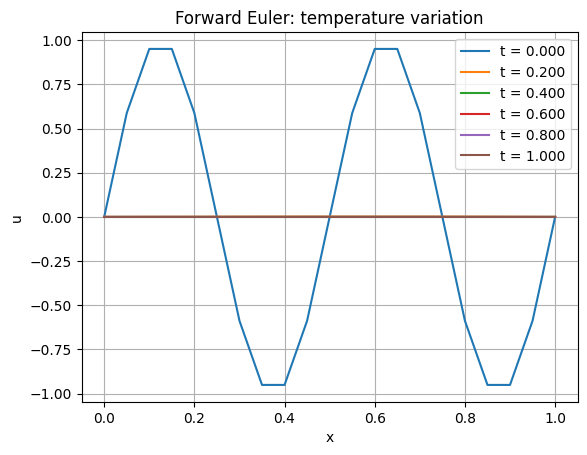

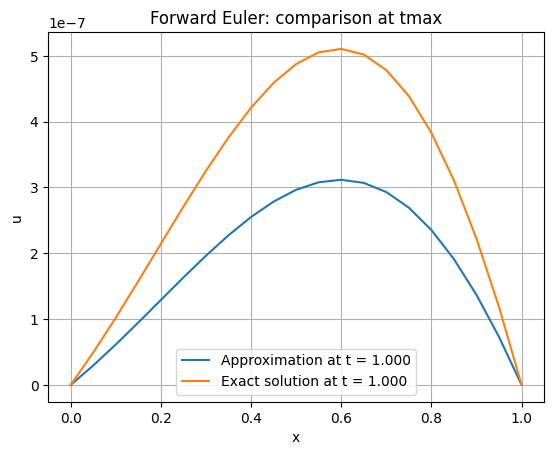

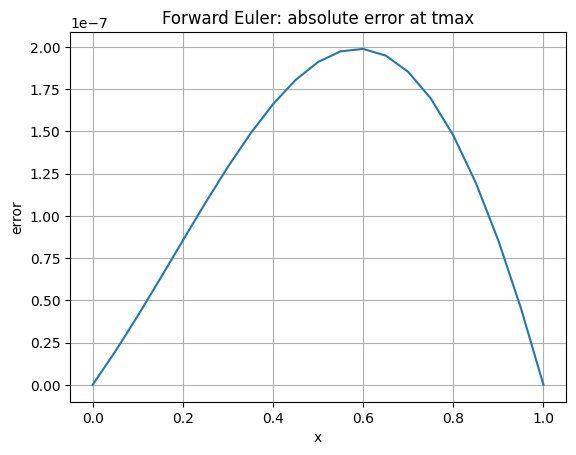

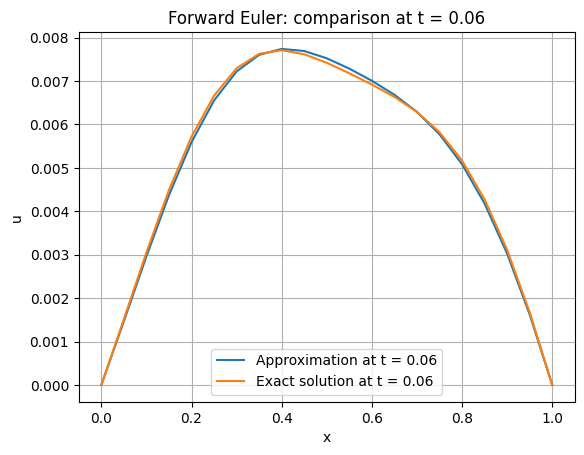

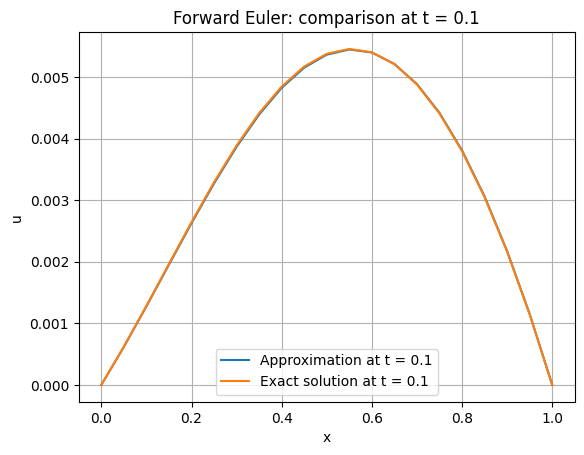

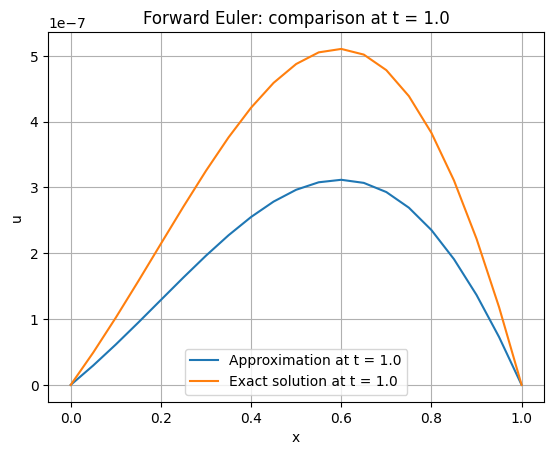

Backward Euler Linf at tmax = 5.10442771790404e-07


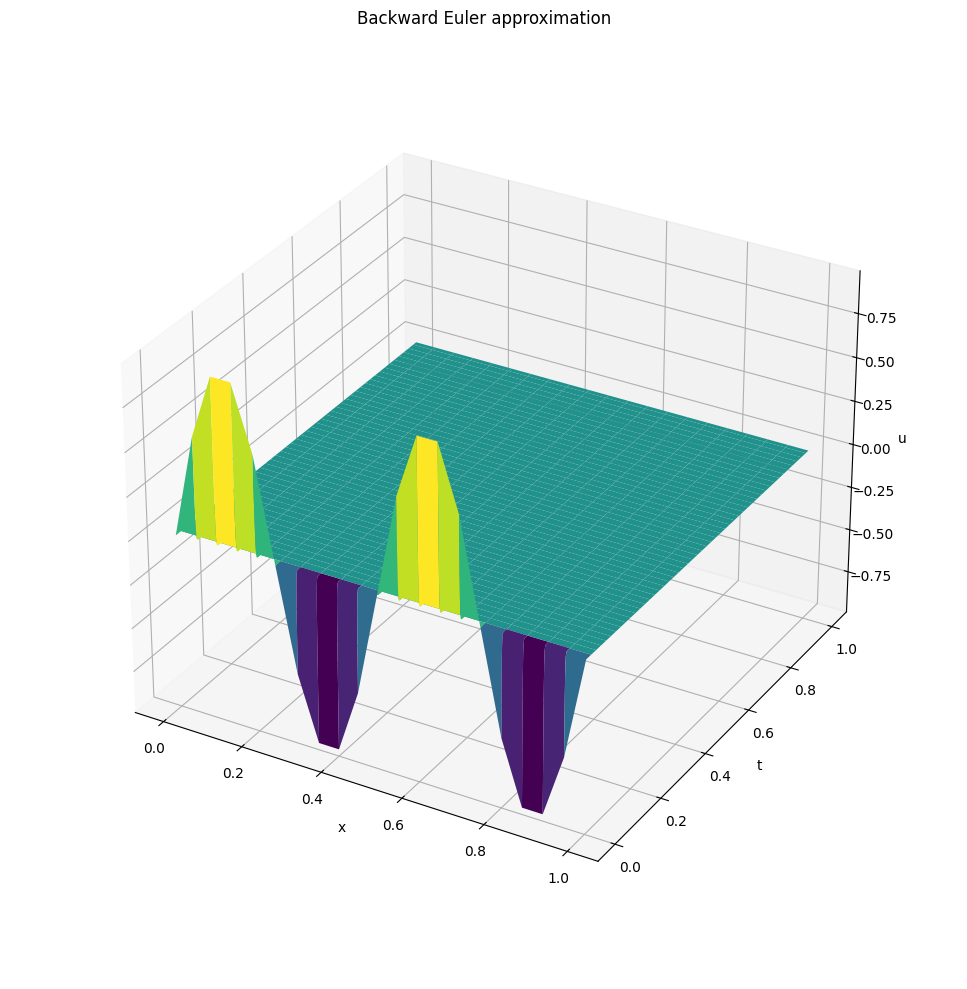

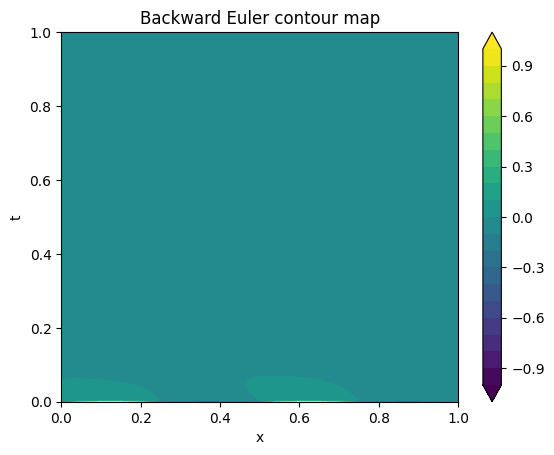

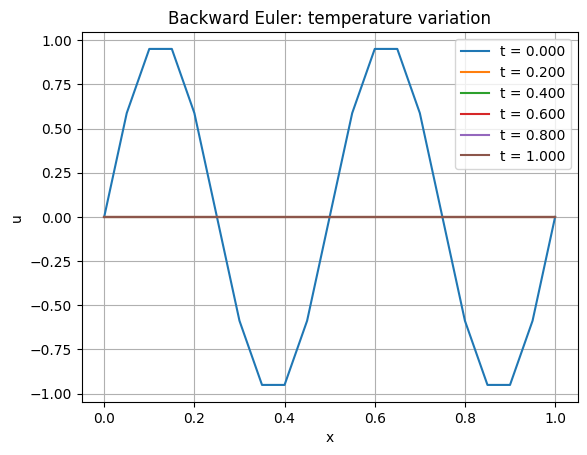

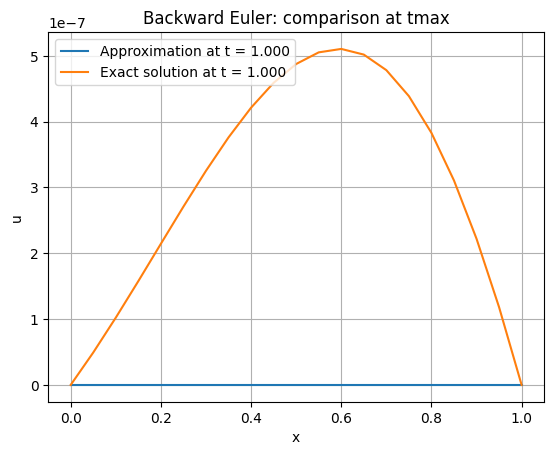

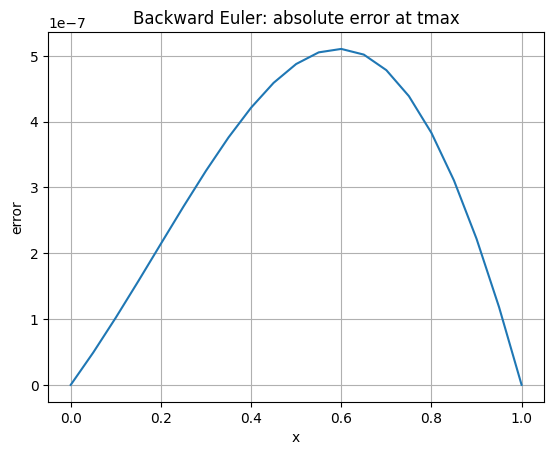

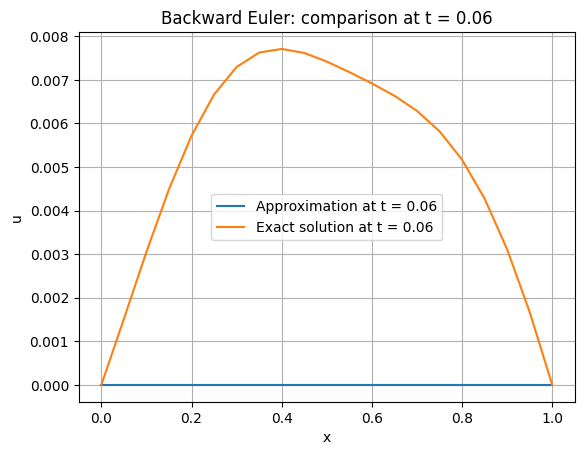

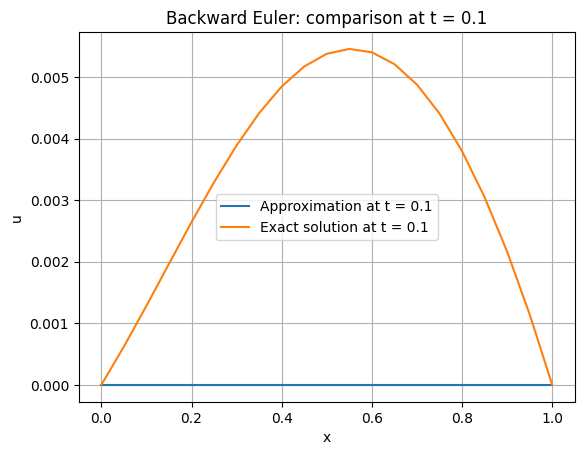

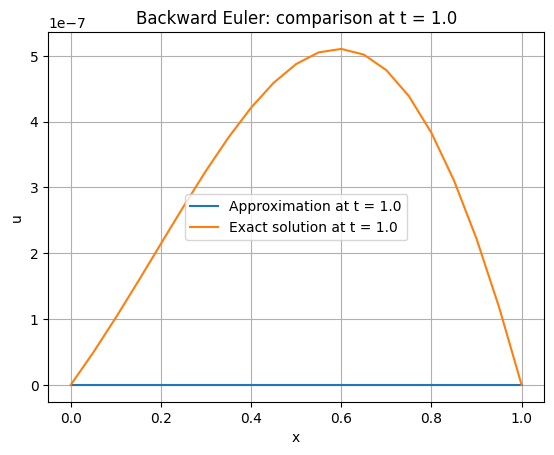

Crank-Nicolson Linf at tmax = 8.020122166908051e-07


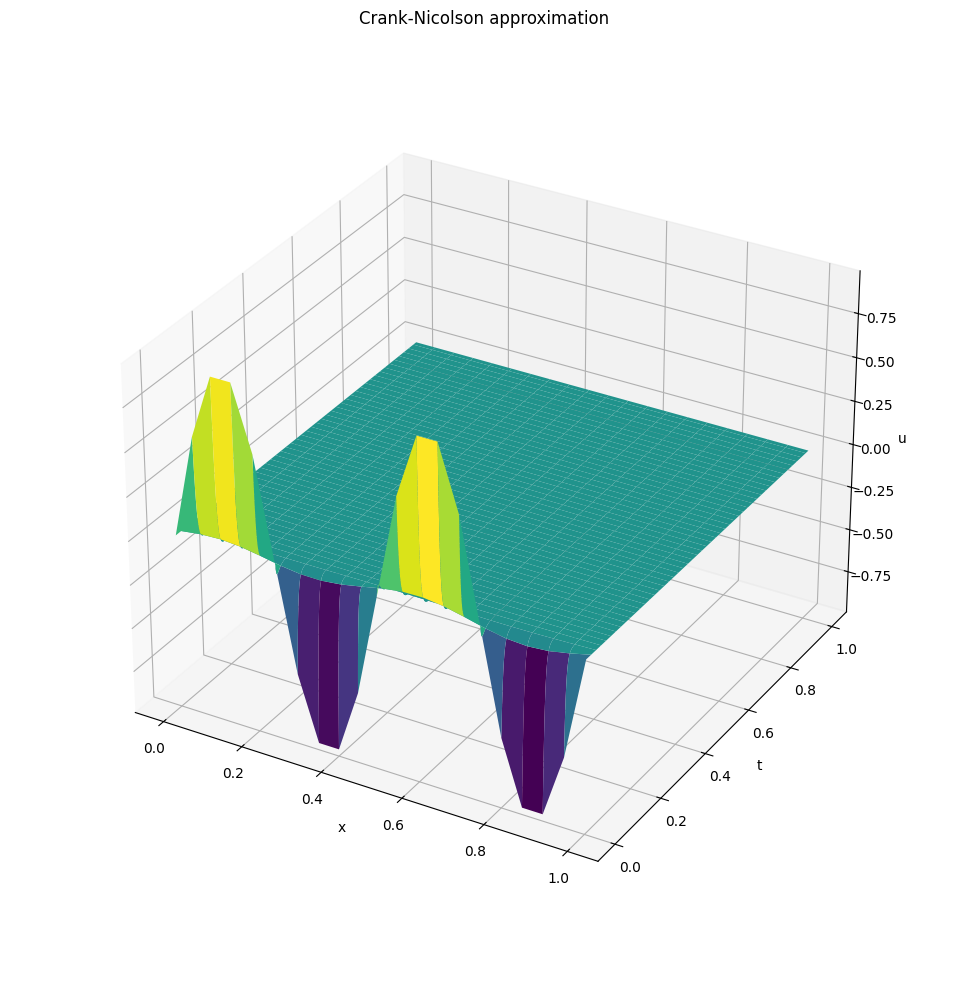

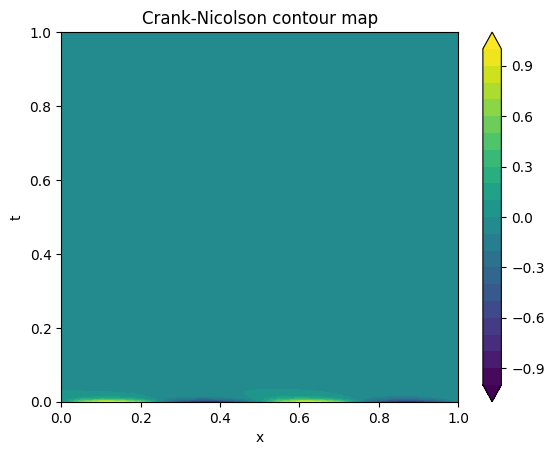

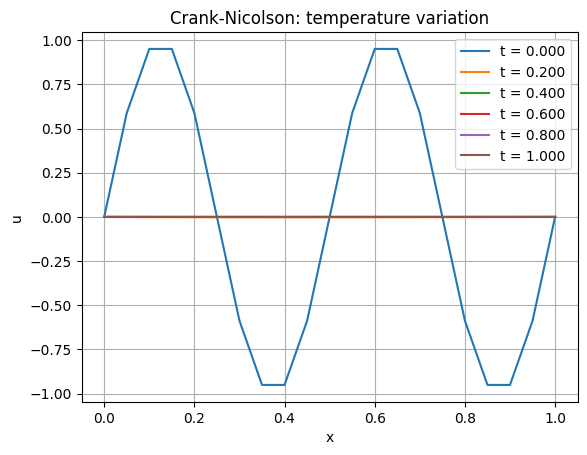

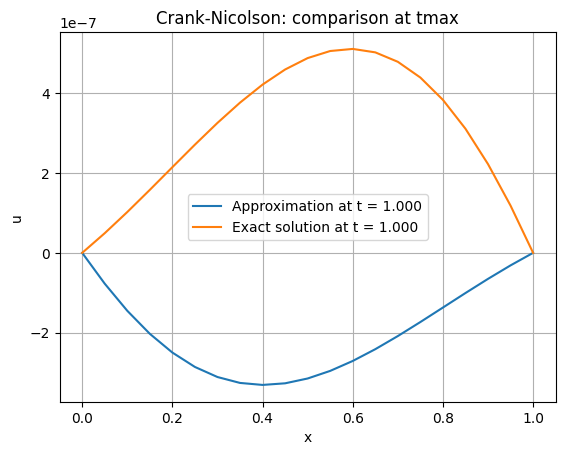

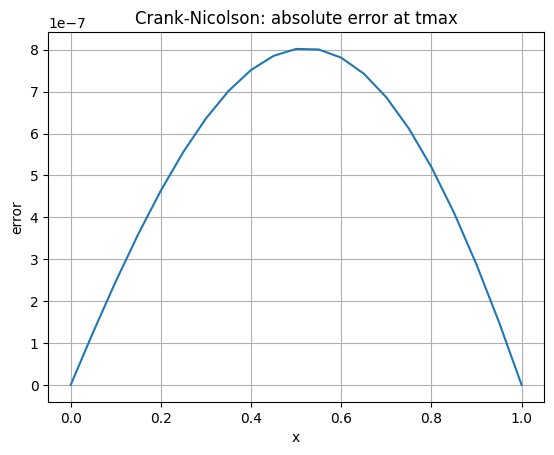

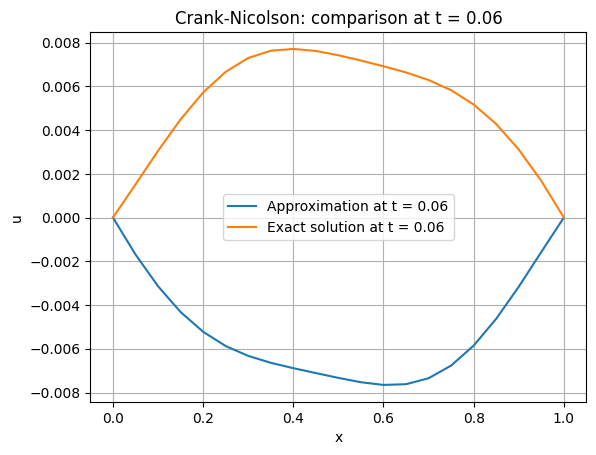

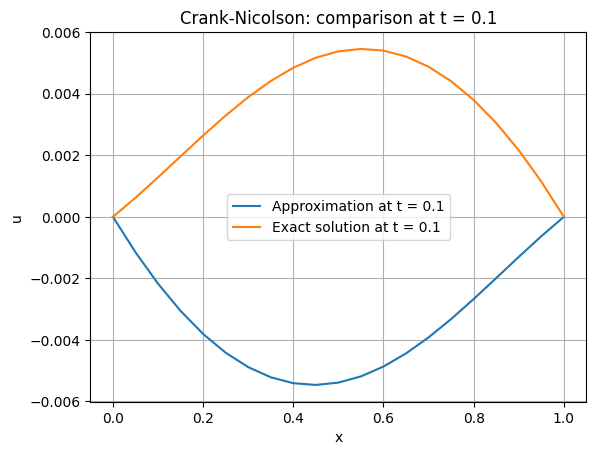

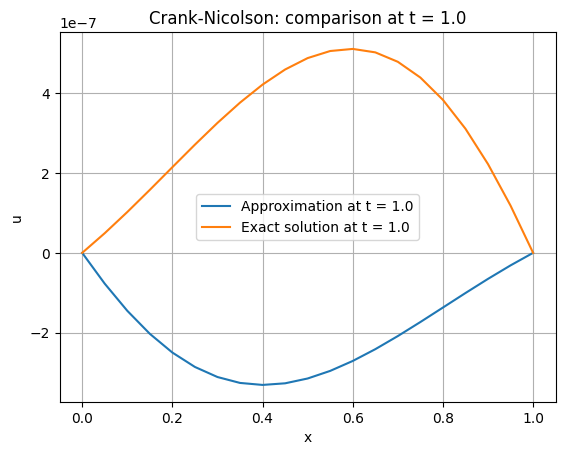

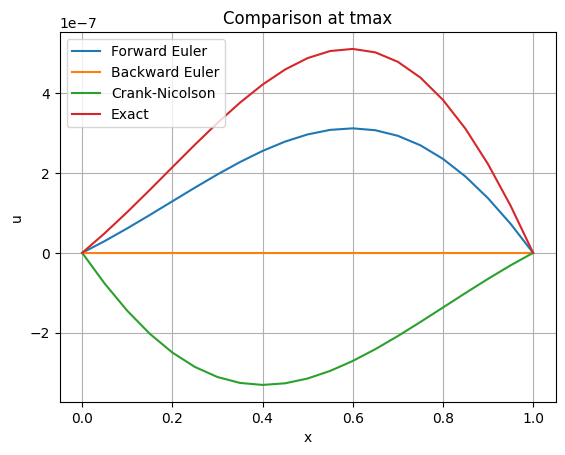

=== Caso D=1.0, N=40 ===


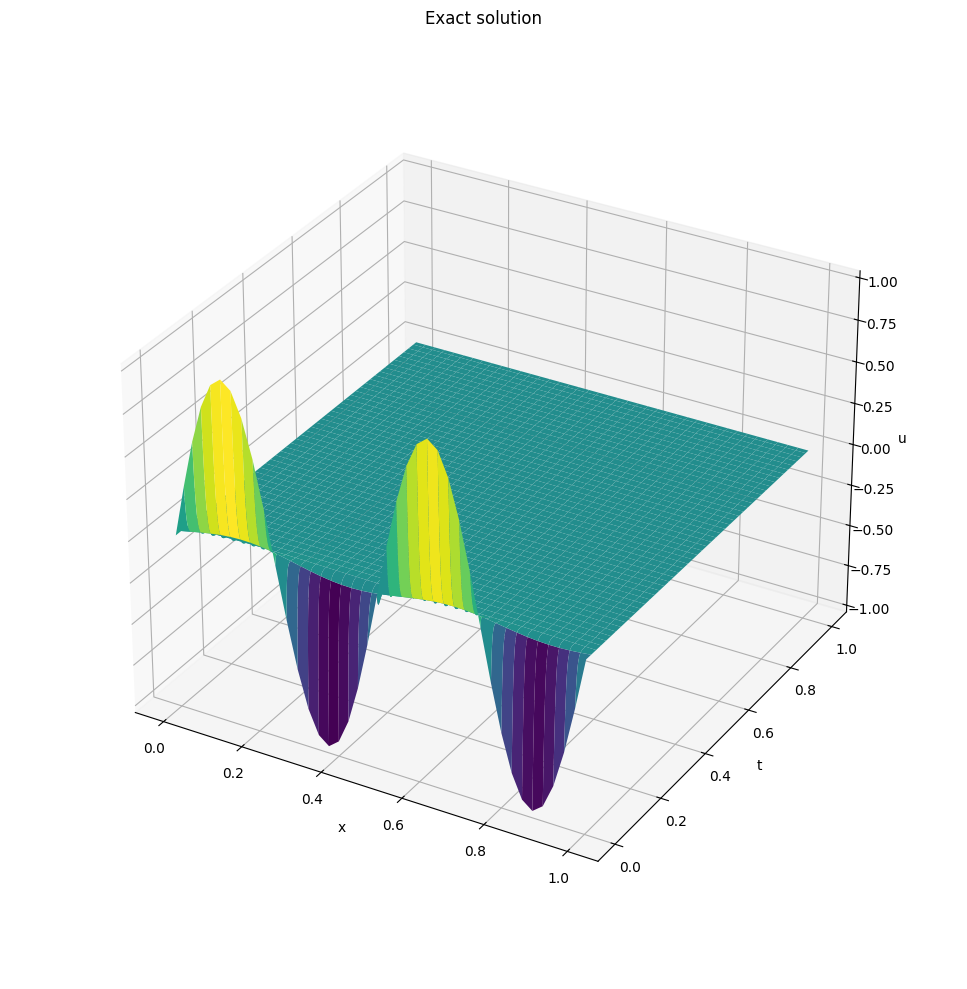

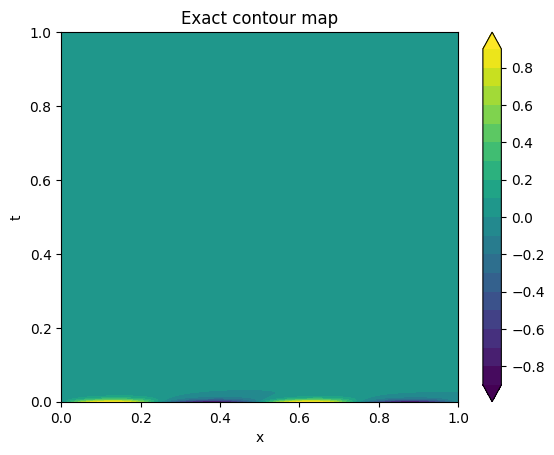

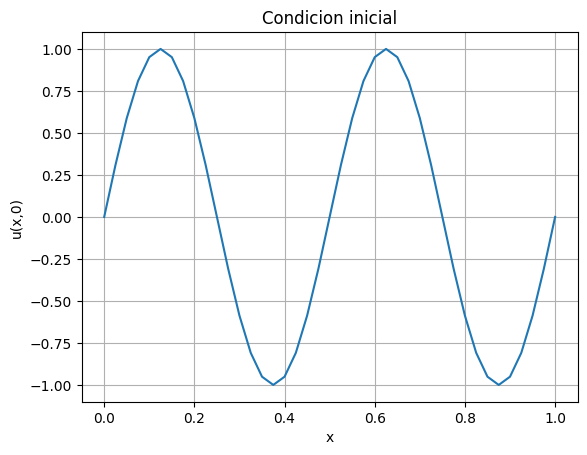

Error: Forward Euler unstable for D=1.0, N=40: s=1.600, alpha=0.040. Reduce dt or N.


UnboundLocalError: cannot access local variable 'u_fwd' where it is not associated with a value

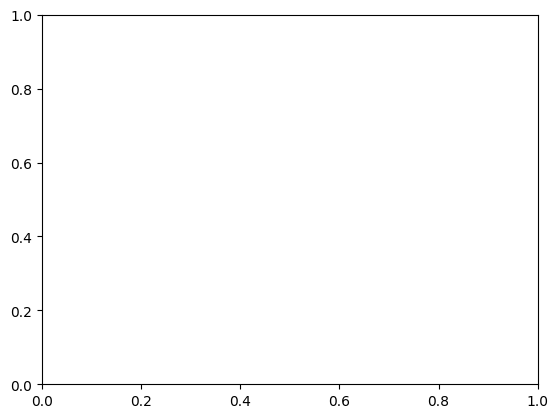

In [28]:
def plot_exact(u_exact, tmin, tmax, title_prefix="Exact"):
    nx, nt = u_exact.shape
    xx = np.linspace(0.0, 1.0, nx)
    tt = np.linspace(tmin, tmax, nt)
    XX, TT = np.meshgrid(xx, tt)

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10), layout="tight")
    ax.plot_surface(XX, TT, u_exact.T, cmap=cm.viridis)
    ax.set(title=f"{title_prefix} solution", xlabel="x", ylabel="t", zlabel="u")
    ax.set_box_aspect(None, zoom=0.87)
    plt.show()

    fig, ax = plt.subplots()
    ct = ax.contourf(XX, TT, u_exact.T, levels=21, extend="both")
    fig.colorbar(ct)
    ax.set(title=f"{title_prefix} contour map", xlabel="x", ylabel="t")
    plt.show()


def plot_method(u, u_exact_grid, x, t, X, T, levels, method_name, times):
    M = len(t) - 1
    error = u - u_exact_grid

    print(f"{method_name} Linf at tmax = {norm(error[:, M], ord=np.inf)}")

    fig, ax = plt.subplots(subplot_kw={"projection": "3d"}, figsize=(10, 10), layout="tight")
    ax.plot_surface(X, T, u.T, cmap=cm.viridis)
    ax.set(title=f"{method_name} approximation", xlabel="x", ylabel="t", zlabel="u")
    ax.set_box_aspect(None, zoom=0.87)
    plt.show()

    fig, ax = plt.subplots()
    ct = ax.contourf(X, T, u.T, levels=levels, extend="both")
    fig.colorbar(ct)
    ax.set(title=f"{method_name} contour map", xlabel="x", ylabel="t")
    plt.show()

    fig, ax = plt.subplots()
    for k in range(0, M+1, max(1, M//5)):
        ax.plot(x, u[:, k], label=f"t = {t[k]:.3f}")
    ax.set(title=f"{method_name}: temperature variation", xlabel="x", ylabel="u")
    ax.grid()
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x, u[:, M], label=f"Approximation at t = {t[M]:.3f}")
    ax.plot(x, u_exact_grid[:, M], label=f"Exact solution at t = {t[M]:.3f}")
    ax.set(title=f"{method_name}: comparison at tmax", xlabel="x", ylabel="u")
    ax.grid()
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()
    ax.plot(x, abs(error[:, M]))
    ax.set(title=f"{method_name}: absolute error at tmax", xlabel="x", ylabel="error")
    ax.grid()
    plt.show()

    for tt in times:
        idx = int(round(tt / dt))
        fig, ax = plt.subplots()
        ax.plot(x, u[:, idx], label=f"Approximation at t = {tt}")
        ax.plot(x, u_exact_grid[:, idx], label=f"Exact solution at t = {tt}")
        ax.set(title=f"{method_name}: comparison at t = {tt}", xlabel="x", ylabel="u")
        ax.grid()
        ax.legend()
        plt.show()


def run_case(D, N):
    print(f"=== Caso D={D}, N={N} ===")
    u_exact, u_exact_grid = load_exact(D, N)

    # test without exact solution (Arreglar)
    # u_exact, u_exact_grid = np.zeros((N+1, M+1)), np.zeros((N+1, M+1))
    
    x, t, dx, M, s, r, X, T, levels = setup_case(D, N)

    if u_exact_grid.shape != (N+1, M+1):
        raise ValueError(
            f"La solucion exacta discretizada tiene forma {u_exact_grid.shape}, se esperaba {(N+1, M+1)}"
        )

    # Graficas de solucion exacta
    plot_exact(u_exact, tmin, tmax, title_prefix="Exact")

    # Condicion inicial
    fig, ax = plt.subplots()
    ax.plot(x, f(x))
    ax.set(title="Condicion inicial", xlabel="x", ylabel="u(x,0)")
    ax.grid()
    plt.show()

    try: 
        # Forward Euler
        u_fwd, x, t, X, T, levels = forward_euler(D, N)
        plot_method(u_fwd, u_exact_grid, x, t, X, T, levels, "Forward Euler", times_to_plot)

        # Backward Euler
        u_bwd, x, t, X, T, levels = backward_euler(D, N)
        plot_method(u_bwd, u_exact_grid, x, t, X, T, levels, "Backward Euler", times_to_plot)

        # Crank-Nicolson
        u_cn, x, t, X, T, levels = crank_nicolson(D, N)
        plot_method(u_cn, u_exact_grid, x, t, X, T, levels, "Crank-Nicolson", times_to_plot)
    except ValueError as e:
        print(f"Error: {e}")

    # Comparacion de metodos en tmax
    fig, ax = plt.subplots()
    ax.plot(x, u_fwd[:, M], label="Forward Euler")
    ax.plot(x, u_bwd[:, M], label="Backward Euler")
    ax.plot(x, u_cn[:, M], label="Crank-Nicolson")
    ax.plot(x, u_exact_grid[:, M], label="Exact")
    ax.set(title="Comparison at tmax", xlabel="x", ylabel="u")
    ax.grid()
    ax.legend()
    plt.show()


for D in D_values:
    for N in N_values:
        run_case(D, N)
